[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kevin-blasiak-curtin/ISYS2001-Archive/blob/main/Module%2008%20-%20API/lab_ticket_stock_chart.ipynb)

# Lab Ticket: Charting Real Stock Data

This week you used the Gemini API: you sent it text, and it sent text back. A stock service works the same way. You send a request (which company, what kind of data) and it sends back a structured response you can turn into a chart.

Your job is to fetch real stock data and draw one clear figure from it. The fetching is written for you. The figure is yours.

## The brief

**API to integrate:** Alpha Vantage (free).

Get your own key the same way you got your Gemini key:

1. Sign up at https://www.alphavantage.co/support/#api-key
2. Store it in Colab Secrets as `ALPHAVANTAGE_API_KEY`, with Notebook access switched on.

Use your own key, not the shared `demo` key. The demo key only ever returns data for IBM.

**Figure I expect:** a line chart of the daily closing price for one ticker of your choice, across the window the data covers. Label both axes, and give the chart a title that names the ticker.

**A note on limits:** the free key allows only about 25 requests a day. Run the fetch cell once. After that the data lives in a DataFrame called `prices`, so do all your charting from that. Re-running the fetch cell over and over will use up your daily quota, and you will start getting a notice instead of data.

In [11]:
from google.colab import userdata
import requests
import pandas as pd
import matplotlib.pyplot as plt

API_KEY = userdata.get("ALPHAVANTAGE_API_KEY")


def get_stock_data(ticker):
    """Fetch daily prices for a ticker and return a tidy DataFrame.

    The result has a date index and Open, High, Low, Close and Volume columns,
    sorted from oldest to newest.
    """
    url = "https://www.alphavantage.co/query"
    params = {
        "function": "TIME_SERIES_DAILY",
        "symbol": ticker,
        "apikey": API_KEY,
        "outputsize": "compact",   # the most recent 100 trading days
    }

    response = requests.get(url, params=params)
    data = response.json()

    # If the expected data is missing, Alpha Vantage explains why here: an
    # invalid ticker, a missing key, or a note that you have hit the daily limit.
    if "Time Series (Daily)" not in data:
        reason = (data.get("Error Message")
                  or data.get("Note")
                  or data.get("Information")
                  or data)
        raise ValueError(f"No price data returned. Alpha Vantage said: {reason}")

    prices = pd.DataFrame.from_dict(data["Time Series (Daily)"], orient="index")
    prices = prices.rename(columns={
        "1. open": "Open",
        "2. high": "High",
        "3. low": "Low",
        "4. close": "Close",
        "5. volume": "Volume",
    })
    prices = prices.astype(float)
    prices.index = pd.to_datetime(prices.index)
    prices = prices.sort_index()
    return prices

In [12]:
# Run this once. Change the ticker to one of your choice.
prices = get_stock_data("AAPL")
prices.tail()

,Open,High,Low,Close,Volume
2026-09-04,328.305,328.93,317.86,319.97,39606884.0
2026-09-08,317.100,320.70,314.90,316.22,35477090.0
2026-09-09,315.485,319.15,309.90,315.34,65639962.0
2026-09-10,316.670,326.74,316.51,326.57,70011913.0
2026-09-11,327.450,336.22,326.30,332.27,50716865.0


In [13]:
# Your chart from here.
# Draw the daily closing price as a labelled line chart, using the `prices` DataFrame.
prices = get_stock_data("GOOGL")
prices.tail()

,Open,High,Low,Close,Volume
2026-09-04,342.465,343.53,337.09,338.46,23189321.0
2026-09-08,335.420,339.68,333.22,338.36,22915839.0
2026-09-09,331.650,331.85,327.90,330.65,33151627.0
2026-09-10,328.225,333.23,327.74,332.60,23557551.0
2026-09-11,335.030,342.98,335.03,338.50,24708293.0


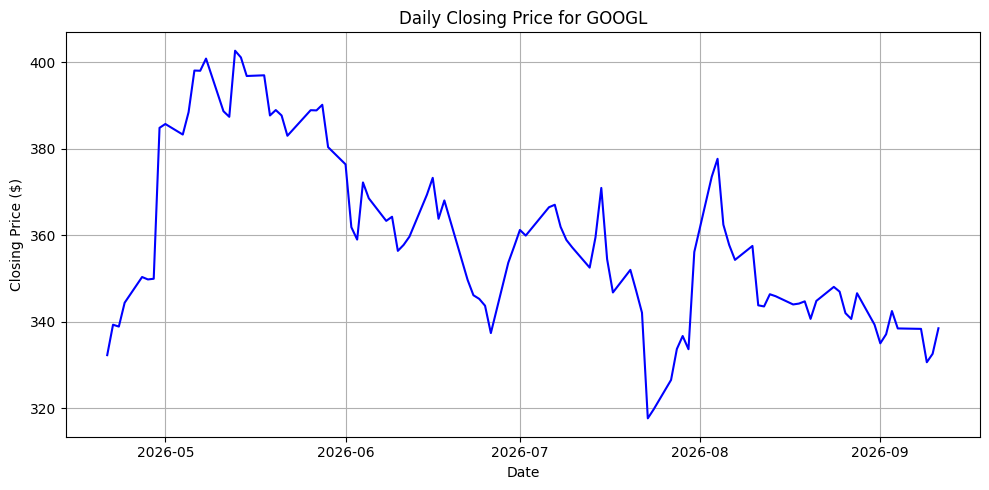

In [16]:
prices = get_stock_data("GOOGL")
prices.tail()
import matplotlib.pyplot as plt

# Create the figure and plot the line chart
plt.figure(figsize=(10, 5))
plt.plot(prices.index, prices['Close'], label='Closing Price', color='blue')

# Label both axes and set the required title with the ticker name
plt.title('Daily Closing Price for GOOGL')
plt.xlabel('Date')
plt.ylabel('Closing Price ($)')

# Display the grid and render the plot
plt.grid(True)
plt.tight_layout()
plt.show()

## Before you finish

Be ready to explain, in your own words:

- what the fetch returns, and what a single row represents
- why a line chart suits this kind of data
- what your finished chart actually shows

**Stretch (optional):** add a second ticker to the same chart, or work out a simple moving average and plot it alongside the price. A moving average needs no extra request, since it is worked out from the data you already have.